<a href="https://colab.research.google.com/github/chrisandrachristopher12-max/IMDB-Movie-Rating-Predictions-Group-10/blob/main/Coding_Milestone_1_MLDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== RAW DATASET PREVIEW ===
                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0  

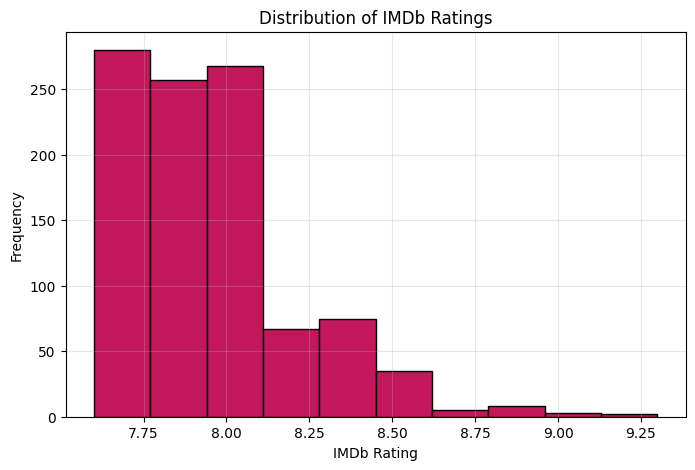

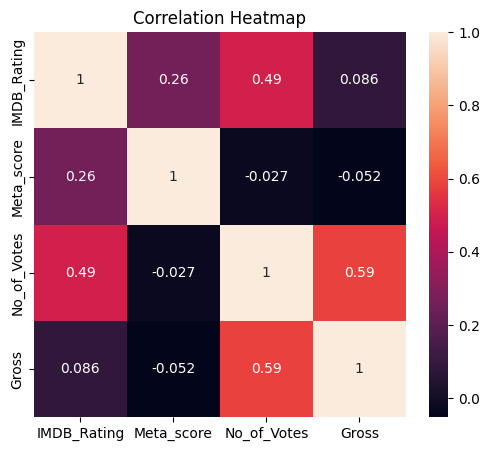


Clean dataset saved as IMDB_Movie_Dataset.csv

Milestone 1 Completed!
Raw dataset loaded from GitHub, cleaned, and preprocessed.
Clean dataset is ready for machine learning.


In [ ]:
# MILESTONE 1: DATA PIPELINE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


# STEP 1: LOAD RAW DATASET FROM GITHUB
RAW_DATA_URL = (
    "https://raw.githubusercontent.com/"
    "chrisandrachristopher12-max/"
    "IMDB-Movie-Rating-Predictions-Group-10/"
    "main/Uncleaned_IMDB_Movie_Dataset.csv"
)

df = pd.read_csv(RAW_DATA_URL)

print("=== RAW DATASET PREVIEW ===")
print(df.head())

print("\nOriginal Shape:", df.shape)


# STEP 2: CHECK DATA PROBLEMS
print("\n=== DATA INFO BEFORE CLEANING ===")
print(df.info())

print("\n=== MISSING VALUES BEFORE CLEANING ===")
print(df.isnull().sum())

print("\n=== DUPLICATES BEFORE CLEANING ===")
print(df.duplicated().sum())


# STEP 3: DATA CLEANING
# Convert columns to numeric format
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")
df["Runtime_min"] = df["Runtime"].astype(str).str.extract(r"(\d+)").astype(float)

df["Gross"] = pd.to_numeric(
    df["Gross"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["No_of_Votes"] = pd.to_numeric(
    df["No_of_Votes"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")
df["IMDB_Rating"] = pd.to_numeric(df["IMDB_Rating"], errors="coerce")

# Fill missing categorical values
df["Certificate"] = df["Certificate"].fillna("Unknown")

# Fill missing numerical values using median
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())
df["Gross"] = df["Gross"].fillna(df["Gross"].median())

# Remove duplicate rows
df = df.drop_duplicates()

print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())

print("\nCleaned Shape:", df.shape)


# STEP 4: PREPROCESSING
le = LabelEncoder()

for col in ["Genre", "Certificate"]:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

print("\nCategorical data encoded successfully.")


# STEP 5: VISUALIZATION
# Distribution of IMDb Ratings
plt.figure(figsize=(8, 5))
df["IMDB_Rating"].hist(
    bins=10,
    color="#C2185B",
    edgecolor="black"
)
plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# Correlation Heatmap
cols = ["IMDB_Rating", "Meta_score", "No_of_Votes", "Gross"]

plt.figure(figsize=(6, 5))
sns.heatmap(df[cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


# STEP 6: SAVE CLEAN DATASET
df.to_csv("IMDB_Movie_Dataset.csv", index=False)

print("\nClean dataset saved as IMDB_Movie_Dataset.csv")


# FINAL MESSAGE
print("\nMilestone 1 Completed!")
print("Raw dataset loaded from GitHub, cleaned, and preprocessed.")
print("Clean dataset is ready for machine learning.")
